# Latent Ablation Study: Turning Off Latent Layers

In this notebook, we take a trained NVAE model and turn off some latent layers during reconstruction and generation, to see how it deteriorates the reconstruction and generation quality.

This is a more rigorous analysis of posterior collapse. First, we can take a look at the KL divergence train graphs for each layer. If the KL divergence is close to 0, it is an indicator of potential posterior collapse. To verify this, we can turn off this layer and see if it affects evaluation performance.

## Preliminaries

The repository assumes all entry points to be run as modules from root. Since
this notebook is 2 levels deep, the below block moves us to the root directory.

In [1]:
import os

# Change this variable if the root folder name has been changed
root_dir = "nvae-shape-encoding"
current_dir = os.getcwd()

if not current_dir.endswith(root_dir):
    %cd ../..

assert os.getcwd().endswith(root_dir)

/Users/freddy/Desktop/Unshared/nvae-shape-encoding


/Users/freddy/Desktop/Unshared/nvae-shape-encoding/venv/lib/python3.11/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


Update `model_path` to choose the model.

In [2]:
import lightning as L
import torch

from arch.nvae.nvae import NVAE
from const import SEED
from data_modules.acdc import ACDCMaskDataModule
from utils.utils import setup_device

model_path = "logs/nvae_acdc/new-arch-2/checkpoints/epoch=99-step=21400.ckpt"

# Setup device
device = setup_device()
print(f"Device: {device}")

# Seed
L.seed_everything(SEED)

# Load data
data_module = ACDCMaskDataModule(batch_size=20)

# Reseed after preprocessing data
L.seed_everything(SEED)

# Load model
model = NVAE.load_from_checkpoint(model_path)

/Users/freddy/Desktop/Unshared/nvae-shape-encoding/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Seed set to 1969


Device: mps
Preprocessed training data found. Loading...
Preprocessed test data found. Loading...


Seed set to 1969


## Reconstruction

First, let's look at reconstruction quality.

NVAE has a shared encoder-decoder architecture. During the top-down pass, the encoder shares information with the decoder to build the residual distribution at each layer. Here, by turning off a layer, we prevent information from being shared.

In [3]:
loader_test = data_module.test_dataloader()
x = next(iter(loader_test))
x.shape

torch.Size([20, 4, 128, 128])

Refer to the docstring of the forward pass in the NVAE decoder class (`arch/nvae/decoder.py`). Update `num_shared_layers` on line 9.

tensor(29915.2305, device='mps:0')


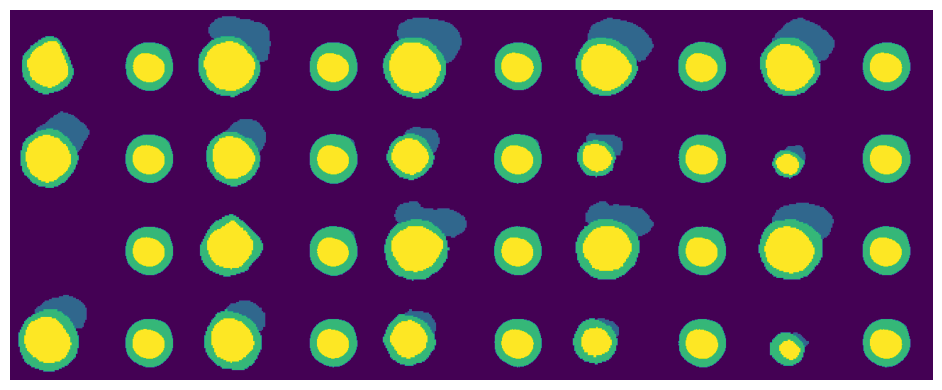

In [4]:
from utils.eval import get_samples_and_reconstructions
from utils.utils import show_samples

with torch.no_grad():
    model.eval()
    model.to(device)
    x = x.to(device)
    
    x_hat_logits, _, _, _, _ = model(x, test=True, num_shared_layers=1)

recon_loss = model.reconstruction_loss(x, x_hat_logits)
print(recon_loss)

x = x.cpu()
x_hat_logits = x_hat_logits.cpu()

samples_and_reconstructions = get_samples_and_reconstructions(x[:20], x_hat_logits[:20])
show_samples(samples_and_reconstructions, rgb=False, ncol=10, figsize=(10, 4), display=False)

## Generation

Now, let's look at generation quality.

Here, by turning off a layer, we do not sample from its corresponding Normal distribution, but instead take the mean as the latent variable.

Refer to the docstring of `generate` pass in the NVAE decoder class (`arch/nvae/decoder.py`). Update `num_sample_layers` on line 7.

Example: Say we set `num_sample_layers = 1`. This means the only variation comes from the topmost latent layer. If we observe the generated samples to be very similar, it means the topmost layer does not encode much information and has collapsed.

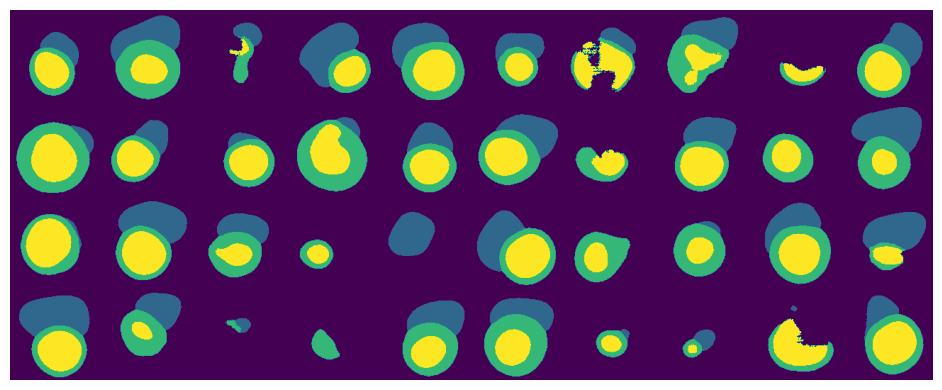

In [14]:
with torch.no_grad():
    model.eval()
    model.to(device)


    # Generate probabilistic segmentation maps
    x_fake = model.decoder.generate(num_samples=40, device=device, num_sample_layers=3)
    feats_fake = model.conditional_coder(x_fake)

# Discretise probabilistic map then view generations
generations = torch.argmax(feats_fake, dim=1).unsqueeze(1)
show_samples(generations, rgb=False, ncol=10, figsize=(10, 4), display=False)